# Baseline Models

This notebook establishes baseline performance for the irrigation need classification task before training more advanced machine learning models.

In [28]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk

In [29]:
data_path = "A:/Projekty Turcja/smart-irrigation-ai/data/raw/irrigation_prediction.csv"

df = pd.read_csv(data_path)
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [30]:
x = df.drop(columns="Irrigation_Need")
y = df["Irrigation_Need"]

x.shape, y.shape

((10000, 19), (10000,))

## 2. Train-Test Split

The dataset is divided into training and test subsets. Stratification is used to preserve the original class proportions in both subsets.

In [31]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("x_train", x_train.shape) 
print("y_train", y_train.shape)
print("x_test", x_test.shape)
print("y_test", y_test.shape)

x_train (8000, 19)
y_train (8000,)
x_test (2000, 19)
y_test (2000,)


# Stratification

In [32]:
print("Training set:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest set:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training set:
Irrigation_Need
Low       58.64
Medium    38.00
High       3.36
Name: proportion, dtype: float64

Test set:
Irrigation_Need
Low       58.65
Medium    38.00
High       3.35
Name: proportion, dtype: float64


## 3. Dummy Classifier

A Dummy Classifier is used as a baseline model. It does not learn meaningful relationships between the input features and the target variable. Instead, it follows a simple prediction strategy, providing a reference point for evaluating more advanced models.

In [33]:
from sklearn.dummy import DummyClassifier 

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(x_train, y_train)
y_pred_dummy = dummy_model.predict(x_test)
y_pred_dummy[:10]

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_dummy)
dummy_macro_f1 = f1_score(y_test, y_pred_dummy, average="macro")

print("Accuracy:", round(dummy_accuracy, 4))
print("Balanced Accuracy:", round(dummy_balanced_accuracy, 4))
print("Macro F1 Score:", round(dummy_macro_f1, 4))


Accuracy: 0.5865
Balanced Accuracy: 0.3333
Macro F1 Score: 0.2465


ConfusionMatrix

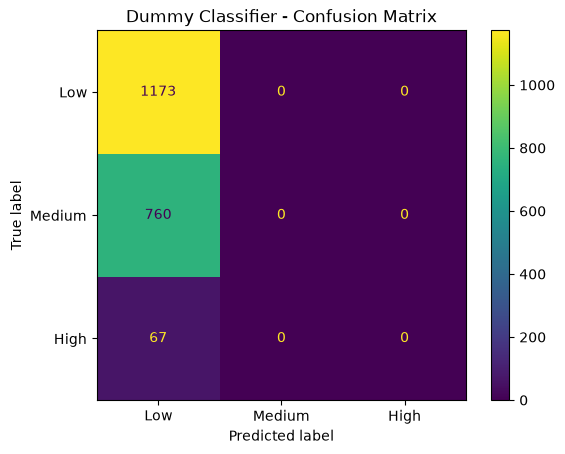

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_dummy, labels=["Low", "Medium", "High"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"])
disp.plot()
plt.title("Dummy Classifier - Confusion Matrix")
plt.show()


## 4. Logistic Regression

Logistic Regression is used as the first learning-based classification model. 
Before training, categorical variables are encoded and numerical variables are standardized using a preprocessing pipeline.

### 1. Preprocessing

Prepare numerical scaling and categorical encoding for the models below.

In [35]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

import time

# Separate numerical and categorical features
numeric_features = x_train.select_dtypes(include="number").columns
categorical_features = x_train.select_dtypes(exclude="number").columns

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_features)
    ]
)

Numerical features: 11
Categorical features: 8


# 2. Training Four Models

In [36]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []

trained_models = {}

for model_name, classifier in models.items():

    model = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", classifier)
        ]
    )

    start_time = time.perf_counter()

    model.fit(x_train, y_train)

    training_time = time.perf_counter() - start_time

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Macro F1": macro_f1,
        "Training Time [s]": training_time
    })

    trained_models[model_name] = model

    print(f"{model_name} completed in {training_time:.2f} seconds")

Logistic Regression completed in 0.21 seconds
Decision Tree completed in 0.06 seconds
Random Forest completed in 0.70 seconds
Gradient Boosting completed in 6.90 seconds


# 3. Results Table

In [37]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Balanced Accuracy",
    ascending=False
)

results_df.round(4)

,Model,Accuracy,Balanced Accuracy,Macro F1,Training Time [s]
1,Decision Tree,0.9960,0.9924,0.9924,0.0638
3,Gradient Boosting,0.9970,0.9701,0.9831,6.8959
2,Random Forest,0.9725,0.8082,0.8584,0.6963
0,Logistic Regression,0.8255,0.6880,0.7220,0.2057


# 4. Adding the Dummy Classifier to the Comparison Table

In [38]:
dummy_result = pd.DataFrame([{
    "Model": "Dummy Classifier",
    "Accuracy": 0.5865,
    "Balanced Accuracy": 0.3333,
    "Macro F1": 0.2465,
    "Training Time [s]": 0
}])

comparison_df = pd.concat(
    [dummy_result, results_df],
    ignore_index=True
)

comparison_df = comparison_df.sort_values(
    by="Balanced Accuracy",
    ascending=False
)

comparison_df.round(4)

,Model,Accuracy,Balanced Accuracy,Macro F1,Training Time [s]
1,Decision Tree,0.9960,0.9924,0.9924,0.0638
2,Gradient Boosting,0.9970,0.9701,0.9831,6.8959
3,Random Forest,0.9725,0.8082,0.8584,0.6963
4,Logistic Regression,0.8255,0.6880,0.7220,0.2057
0,Dummy Classifier,0.5865,0.3333,0.2465,0.0000


# 1. Decision Tree Classification Report

In [39]:
from sklearn.metrics import classification_report

tree_model = trained_models["Decision Tree"]

y_pred_tree = tree_model.predict(x_test)

print(
    classification_report(
        y_test,
        y_pred_tree,
        digits=4
    )
)

              precision    recall  f1-score   support

        High     0.9851    0.9851    0.9851        67
         Low     0.9974    0.9974    0.9974      1173
      Medium     0.9947    0.9947    0.9947       760

    accuracy                         0.9960      2000
   macro avg     0.9924    0.9924    0.9924      2000
weighted avg     0.9960    0.9960    0.9960      2000



# 2. Decision Tree Confusion Matrix

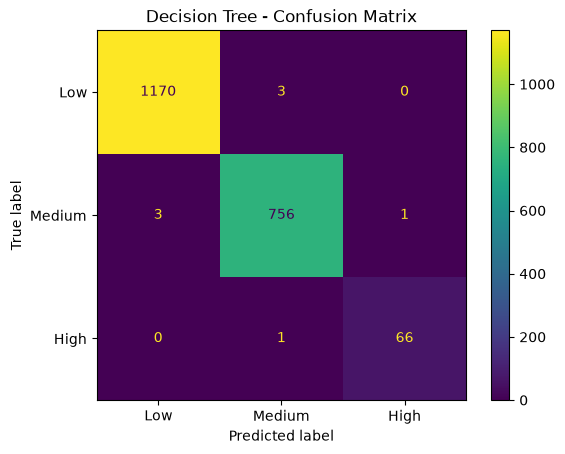

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    labels=["Low", "Medium", "High"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

# 3. Five-Fold Cross-Validation

In [41]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro"
}

tree_cv = cross_validate(
    trained_models["Decision Tree"],
    x_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Decision Tree - 5 Fold Cross Validation")
print(
    "Accuracy:",
    round(tree_cv["test_accuracy"].mean(), 4),
    "+/-",
    round(tree_cv["test_accuracy"].std(), 4)
)

print(
    "Balanced Accuracy:",
    round(tree_cv["test_balanced_accuracy"].mean(), 4),
    "+/-",
    round(tree_cv["test_balanced_accuracy"].std(), 4)
)

print(
    "Macro F1:",
    round(tree_cv["test_macro_f1"].mean(), 4),
    "+/-",
    round(tree_cv["test_macro_f1"].std(), 4)
)

Decision Tree - 5 Fold Cross Validation
Accuracy: 0.9938 +/- 0.0019
Balanced Accuracy: 0.978 +/- 0.0121
Macro F1: 0.9796 +/- 0.0044


# 4 Testing all 4 models

In [42]:
cv_results = []

for model_name, model in trained_models.items():

    scores = cross_validate(
        model,
        x_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Accuracy CV": scores["test_accuracy"].mean(),
        "Balanced Accuracy CV": scores["test_balanced_accuracy"].mean(),
        "Macro F1 CV": scores["test_macro_f1"].mean(),
        "Balanced Accuracy STD": scores["test_balanced_accuracy"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    "Balanced Accuracy CV",
    ascending=False
)

cv_results_df.round(4)

,Model,Accuracy CV,Balanced Accuracy CV,Macro F1 CV,Balanced Accuracy STD
1,Decision Tree,0.9938,0.9780,0.9796,0.0121
3,Gradient Boosting,0.9945,0.9544,0.9725,0.0184
2,Random Forest,0.9689,0.7900,0.8397,0.0104
0,Logistic Regression,0.8301,0.6917,0.7221,0.0210


# CatBoost

In [43]:
from catboost import CatBoostClassifier
import time

categorical_features_catboost = x_train.select_dtypes(
    exclude="number"
).columns.tolist()

catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    random_seed=42,
    verbose=0,
    thread_count=-1
)

start_time = time.perf_counter()

catboost_model.fit(
    x_train,
    y_train,
    cat_features=categorical_features_catboost
)

catboost_time = time.perf_counter() - start_time

y_pred_catboost = catboost_model.predict(x_test).ravel()

catboost_accuracy = accuracy_score(
    y_test,
    y_pred_catboost
)

catboost_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_catboost
)

catboost_macro_f1 = f1_score(
    y_test,
    y_pred_catboost,
    average="macro"
)

print("CatBoost")
print("Accuracy:", round(catboost_accuracy, 4))
print(
    "Balanced Accuracy:",
    round(catboost_balanced_accuracy, 4)
)
print("Macro F1:", round(catboost_macro_f1, 4))
print("Training Time:", round(catboost_time, 4), "s")

CatBoost
Accuracy: 0.9995
Balanced Accuracy: 0.9996
Macro F1: 0.9996
Training Time: 18.0029 s


# XGBoost

In [44]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(
    dict(
        zip(
            label_encoder.classes_,
            label_encoder.transform(label_encoder.classes_)
        )
    )
)

xgb_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist"
            )
        )
    ]
)

# Train the XGBoost model
start_time = time.perf_counter()

xgb_model.fit(
    x_train,
    y_train_encoded
)

xgb_time = time.perf_counter() - start_time

y_pred_xgb = xgb_model.predict(x_test)

# Evaluation metrics
xgb_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_xgb
)

xgb_balanced_accuracy = balanced_accuracy_score(
    y_test_encoded,
    y_pred_xgb
)

xgb_macro_f1 = f1_score(
    y_test_encoded,
    y_pred_xgb,
    average="macro"
)

print("XGBoost")
print("Accuracy:", round(xgb_accuracy, 4))
print(
    "Balanced Accuracy:",
    round(xgb_balanced_accuracy, 4)
)
print("Macro F1:", round(xgb_macro_f1, 4))
print("Training Time:", round(xgb_time, 4), "s")

# Add CatBoost and XGBoost to the existing comparison table
new_results = pd.DataFrame([
    {
        "Model": "CatBoost",
        "Accuracy": catboost_accuracy,
        "Balanced Accuracy": catboost_balanced_accuracy,
        "Macro F1": catboost_macro_f1,
        "Training Time [s]": catboost_time
    },
    {
        "Model": "XGBoost",
        "Accuracy": xgb_accuracy,
        "Balanced Accuracy": xgb_balanced_accuracy,
        "Macro F1": xgb_macro_f1,
        "Training Time [s]": xgb_time
    }
])

final_comparison_df = pd.concat(
    [comparison_df, new_results],
    ignore_index=True
)

final_comparison_df = (
    final_comparison_df
    .drop_duplicates(subset="Model", keep="last")
    .sort_values(
        "Balanced Accuracy",
        ascending=False
    )
)

final_comparison_df.round(4)


{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
XGBoost
Accuracy: 0.995
Balanced Accuracy: 0.9595
Macro F1: 0.9764
Training Time: 1.0173 s


,Model,Accuracy,Balanced Accuracy,Macro F1,Training Time [s]
5,CatBoost,0.9995,0.9996,0.9996,18.0029
0,Decision Tree,0.9960,0.9924,0.9924,0.0638
1,Gradient Boosting,0.9970,0.9701,0.9831,6.8959
6,XGBoost,0.9950,0.9595,0.9764,1.0173
2,Random Forest,0.9725,0.8082,0.8584,0.6963
3,Logistic Regression,0.8255,0.6880,0.7220,0.2057
4,Dummy Classifier,0.5865,0.3333,0.2465,0.0000


## 5. Validation, interpretation and ablation study

Cross-validation and ablation use only `x_train` and `y_train`. Existing fitted
models are cloned, preserving their parameters and previous results. CatBoost
handles categorical features natively; other models fit their preprocessing
inside each training fold.

**Historical CV results:** the two earlier CV cells previously used the complete
dataset (`x`, `y`). Their code now uses the training subset (`x_train`, `y_train`).
Their saved outputs have been preserved and refer to the old protocol until those
cells are rerun. Use the new common-fold comparison table below for the current
training-only validation protocol.

### 5.1. imports and existing model references

In [45]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, recall_score
from IPython.display import display

# Existing objects; preserve their fitted state and hyperparameters.
source_models = {
    "Decision Tree": trained_models["Decision Tree"],
    "Random Forest": trained_models["Random Forest"],
    "XGBoost": xgb_model,
    "CatBoost": catboost_model,
}

model_templates = {}
for name, source in source_models.items():
    classifier = source.steps[-1][1] if isinstance(source, Pipeline) else source
    model_templates[name] = clone(classifier)

class_labels = ["Low", "Medium", "High"]
assert set(y_train.unique()) == set(class_labels)
assert x_train.index.equals(y_train.index)

# CV uses ONLY the 80% training subset; the 20% test subset is not used here.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_splits = list(cv.split(x_train, y_train))

### 5.2. fold-local preprocessing and evaluation helpers

In [46]:
def make_estimator(model_name, X_subset):
    numeric_columns = X_subset.select_dtypes(include="number").columns.tolist()
    categorical_columns = X_subset.select_dtypes(exclude="number").columns.tolist()
    classifier = clone(model_templates[model_name])

    if model_name == "CatBoost":
        # Native categorical handling; names remain correct after dropping columns.
        classifier.set_params(
            cat_features=categorical_columns,
            verbose=False,
            allow_writing_files=False,
            use_best_model=False,
        )
        return classifier

    if model_name == "XGBoost":
        # Fixed hyperparameters/number of trees: no external eval_set or test-based stopping.
        classifier.set_params(early_stopping_rounds=None, callbacks=None)

    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
    ])
    return Pipeline([("preprocessor", preprocessor), ("model", classifier)])


def fit_and_predict(model_name, X_fit, y_fit, X_evaluate):
    estimator = make_estimator(model_name, X_fit)
    if model_name == "XGBoost":
        # Target encoding is fitted on the current training fold only.
        encoder = LabelEncoder().fit(y_fit)
        estimator.fit(X_fit, encoder.transform(y_fit))
        predicted = estimator.predict(X_evaluate).astype(int)
        predicted = encoder.inverse_transform(predicted)
    else:
        estimator.fit(X_fit, y_fit)
        predicted = np.asarray(estimator.predict(X_evaluate)).ravel()
    return estimator, predicted


def evaluate_predictions(y_true, predicted):
    recalls = recall_score(
        y_true, predicted, labels=class_labels, average=None, zero_division=0
    )
    return {
        "Accuracy": accuracy_score(y_true, predicted),
        "Balanced Accuracy": balanced_accuracy_score(y_true, predicted),
        "Macro F1": f1_score(
            y_true, predicted, labels=class_labels, average="macro", zero_division=0
        ),
        **{f"Recall {label}": value for label, value in zip(class_labels, recalls)},
    }


def run_cv(model_name, X_subset):
    rows = []
    for fold, (train_indices, valid_indices) in enumerate(cv_splits, start=1):
        _, predicted = fit_and_predict(
            model_name,
            X_subset.iloc[train_indices], y_train.iloc[train_indices],
            X_subset.iloc[valid_indices],
        )
        rows.append({
            "Model": model_name,
            "Fold": fold,
            **evaluate_predictions(y_train.iloc[valid_indices], predicted),
        })
    return pd.DataFrame(rows)


def summarize_cv(fold_results, group_columns):
    rows = []
    metrics = ["Accuracy", "Balanced Accuracy", "Macro F1"]
    metrics += [f"Recall {label}" for label in class_labels]
    for keys, group in fold_results.groupby(group_columns, sort=False):
        keys = keys if isinstance(keys, tuple) else (keys,)
        row = dict(zip(group_columns, keys))
        for metric in metrics:
            row[f"{metric} CV mean"] = group[metric].mean()
            # Population std across the five scores, matching np.std(scores).
            row[f"{metric} CV std"] = group[metric].std(ddof=0)
        rows.append(row)
    return pd.DataFrame(rows)

### 5.3. CatBoost: 5-fold Stratified CV

In [47]:
catboost_cv_folds = run_cv("CatBoost", x_train)
display(summarize_cv(catboost_cv_folds, ["Model"]).round(4))

,Model,Accuracy CV mean,Accuracy CV std,Balanced Accuracy CV mean,Balanced Accuracy CV std,Macro F1 CV mean,Macro F1 CV std,Recall Low CV mean,Recall Low CV std,Recall Medium CV mean,Recall Medium CV std,Recall High CV mean,Recall High CV std
0,CatBoost,0.9968,0.0018,0.9941,0.006,0.9953,0.0035,0.9979,0.0013,0.9957,0.0034,0.9887,0.0151


### 5.4. XGBoost: 5-fold Stratified CV

In [48]:
xgboost_cv_folds = run_cv("XGBoost", x_train)
display(summarize_cv(xgboost_cv_folds, ["Model"]).round(4))

,Model,Accuracy CV mean,Accuracy CV std,Balanced Accuracy CV mean,Balanced Accuracy CV std,Macro F1 CV mean,Macro F1 CV std,Recall Low CV mean,Recall Low CV std,Recall Medium CV mean,Recall Medium CV std,Recall High CV mean,Recall High CV std
0,XGBoost,0.9951,0.0034,0.9779,0.021,0.9853,0.0119,0.9979,0.0013,0.9957,0.0022,0.9401,0.0602


### 5.5. Decision Tree CV and one comparison table

Recompute Decision Tree on the same folds for a paired comparison. This does not
overwrite its previous CV output. The previously reported mean/std values alone
cannot provide per-fold recall or paired differences.

In [49]:
decision_tree_cv_folds = run_cv("Decision Tree", x_train)

validation_cv_folds = pd.concat(
    [catboost_cv_folds, xgboost_cv_folds, decision_tree_cv_folds],
    ignore_index=True,
)
validation_cv_summary = summarize_cv(validation_cv_folds, ["Model"])
comparison_columns = [
    "Model",
    "Accuracy CV mean", "Accuracy CV std",
    "Balanced Accuracy CV mean", "Balanced Accuracy CV std",
    "Macro F1 CV mean", "Macro F1 CV std",
]
validation_cv_table = validation_cv_summary[comparison_columns].sort_values(
    ["Balanced Accuracy CV mean", "Macro F1 CV mean"], ascending=False
)
display(validation_cv_table.round(4))

recall_columns = ["Model"] + [
    f"Recall {label} CV {stat}"
    for label in class_labels for stat in ["mean", "std"]
]
display(validation_cv_summary[recall_columns].round(4))

,Model,Accuracy CV mean,Accuracy CV std,Balanced Accuracy CV mean,Balanced Accuracy CV std,Macro F1 CV mean,Macro F1 CV std
0,CatBoost,0.9968,0.0018,0.9941,0.0060,0.9953,0.0035
2,Decision Tree,0.9938,0.0019,0.9780,0.0121,0.9796,0.0044
1,XGBoost,0.9951,0.0034,0.9779,0.0210,0.9853,0.0119


,Model,Recall Low CV mean,Recall Low CV std,Recall Medium CV mean,Recall Medium CV std,Recall High CV mean,Recall High CV std
0,CatBoost,0.9979,0.0013,0.9957,0.0034,0.9887,0.0151
1,XGBoost,0.9979,0.0013,0.9957,0.0022,0.9401,0.0602
2,Decision Tree,0.9972,0.0021,0.9928,0.0022,0.9440,0.0358


### 5.6. fit independent copies for training-set interpretation

These copies preserve existing fitted models and their outputs. They use all of
`x_train`; no test scores are calculated or used for choosing features.

In [50]:
interpretation_models = {}
for model_name in model_templates:
    fitted, _ = fit_and_predict(model_name, x_train, y_train, x_train.iloc[:1])
    interpretation_models[model_name] = fitted

interpreted_tree = interpretation_models["Decision Tree"].named_steps["model"]
print("Tree depth:", interpreted_tree.get_depth())
print("Number of leaves:", interpreted_tree.get_n_leaves())

Tree depth: 8
Number of leaves: 64


### 5.7. original-feature importance for all four models

Decision Tree and Random Forest use impurity-based importance. XGBoost uses gain;
CatBoost uses PredictionValuesChange. These are different measures, so compare
rankings within models, not numerical values between models. Impurity importance
can favor continuous features or features with many categories. Importance is
descriptive, not causal, and does not establish whether the target was generated
by a rule.

For one-hot encoded features, sum all category importances back to their original
feature. The encoder below uses its default `drop=None` without category grouping.

,Transformed feature,Original feature,Importance
8,num__Wind_Speed_kmh,Wind_Speed_kmh,0.196230
4,num__Temperature_C,Temperature_C,0.175954
1,num__Soil_Moisture,Soil_Moisture,0.147571
36,cat__Mulching_Used_No,Mulching_Used,0.134812
6,num__Rainfall_mm,Rainfall_mm,0.118952
24,cat__Crop_Growth_Stage_Vegetative,Crop_Growth_Stage,0.086407
21,cat__Crop_Growth_Stage_Flowering,Crop_Growth_Stage,0.061006
23,cat__Crop_Growth_Stage_Sowing,Crop_Growth_Stage,0.034323
37,cat__Mulching_Used_Yes,Mulching_Used,0.023681
22,cat__Crop_Growth_Stage_Harvest,Crop_Growth_Stage,0.019667


,Feature,Importance,Normalized importance
0,Crop_Growth_Stage,0.2014,0.2014
1,Wind_Speed_kmh,0.1962,0.1962
2,Temperature_C,0.1760,0.1760
3,Mulching_Used,0.1585,0.1585
4,Soil_Moisture,0.1476,0.1476
5,Rainfall_mm,0.1190,0.1190
6,Electrical_Conductivity,0.0009,0.0009
7,Organic_Carbon,0.0004,0.0004
8,Field_Area_hectare,0.0001,0.0001
9,Soil_pH,0.0000,0.0000


Decision Tree


,Feature,Importance,Normalized importance
0,Crop_Growth_Stage,0.2014,0.2014
1,Wind_Speed_kmh,0.1962,0.1962
2,Temperature_C,0.1760,0.1760
3,Mulching_Used,0.1585,0.1585
4,Soil_Moisture,0.1476,0.1476
5,Rainfall_mm,0.1190,0.1190
6,Electrical_Conductivity,0.0009,0.0009
7,Organic_Carbon,0.0004,0.0004
8,Field_Area_hectare,0.0001,0.0001
9,Soil_pH,0.0000,0.0000


Random Forest


,Feature,Importance,Normalized importance
0,Crop_Growth_Stage,0.2214,0.2214
1,Soil_Moisture,0.1800,0.1800
2,Wind_Speed_kmh,0.0945,0.0945
3,Temperature_C,0.0910,0.0910
4,Rainfall_mm,0.0894,0.0894
5,Mulching_Used,0.0782,0.0782
6,Humidity,0.0241,0.0241
7,Previous_Irrigation_mm,0.0239,0.0239
8,Field_Area_hectare,0.0236,0.0236
9,Sunlight_Hours,0.0235,0.0235


XGBoost


,Feature,Importance,Normalized importance
0,Crop_Growth_Stage,0.3253,0.3253
1,Mulching_Used,0.1766,0.1766
2,Soil_Moisture,0.1192,0.1192
3,Wind_Speed_kmh,0.0815,0.0815
4,Rainfall_mm,0.0737,0.0737
5,Temperature_C,0.0725,0.0725
6,Region,0.0284,0.0284
7,Crop_Type,0.0245,0.0245
8,Irrigation_Type,0.0205,0.0205
9,Soil_Type,0.0189,0.0189


CatBoost


,Feature,Importance,Normalized importance
0,Crop_Growth_Stage,26.4268,0.2643
1,Soil_Moisture,21.1394,0.2114
2,Mulching_Used,14.7100,0.1471
3,Wind_Speed_kmh,13.5888,0.1359
4,Temperature_C,12.8489,0.1285
5,Rainfall_mm,10.0989,0.1010
6,Electrical_Conductivity,0.1738,0.0017
7,Humidity,0.1612,0.0016
8,Sunlight_Hours,0.1489,0.0015
9,Field_Area_hectare,0.1333,0.0013


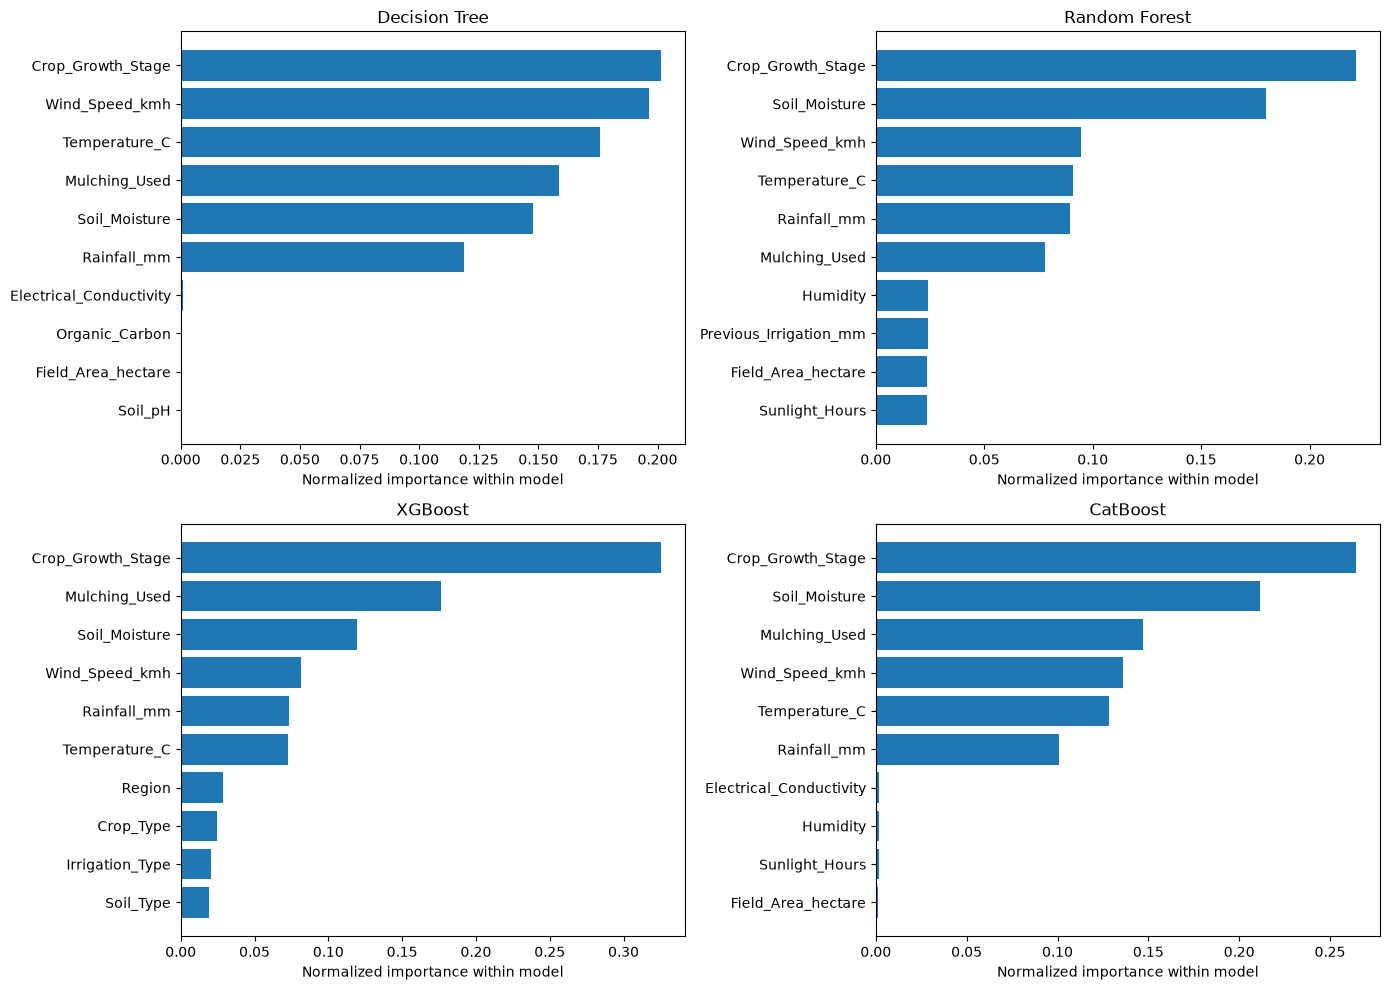

In [51]:
def original_feature_importance(model_name, fitted, X_reference):
    if model_name == "CatBoost":
        names = list(fitted.feature_names_)
        values = fitted.get_feature_importance(type="PredictionValuesChange")
        result = pd.Series(values, index=names, name="Importance")
        transformed_table = result.rename_axis("Transformed feature").reset_index()
    else:
        preprocessor = fitted.named_steps["preprocessor"]
        classifier = fitted.named_steps["model"]
        if model_name == "XGBoost":
            classifier.set_params(importance_type="gain")
        values = classifier.feature_importances_
        numeric_columns = X_reference.select_dtypes(include="number").columns.tolist()
        categorical_columns = X_reference.select_dtypes(exclude="number").columns.tolist()
        original_names = numeric_columns.copy()
        if categorical_columns:
            encoder = preprocessor.named_transformers_["cat"]
            for column, categories in zip(categorical_columns, encoder.categories_):
                original_names.extend([column] * len(categories))
        assert len(values) == len(original_names)
        transformed_table = pd.DataFrame({
            "Transformed feature": preprocessor.get_feature_names_out(),
            "Original feature": original_names,
            "Importance": values,
        }).sort_values("Importance", ascending=False)
        result = pd.Series(values, index=original_names).groupby(level=0).sum()

    result = result.reindex(X_reference.columns, fill_value=0)
    total = result.sum()
    normalized = result / total if total > 0 else result
    table = pd.DataFrame({
        "Feature": result.index,
        "Importance": result.values,
        "Normalized importance": normalized.values,
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    return table, transformed_table


importance_tables = {}
transformed_importance_tables = {}
for model_name, fitted in interpretation_models.items():
    table, transformed_table = original_feature_importance(model_name, fitted, x_train)
    importance_tables[model_name] = table
    transformed_importance_tables[model_name] = transformed_table

# Full feature_importances_ table after scaling and one-hot encoding.
decision_tree_transformed_importance = transformed_importance_tables["Decision Tree"]
display(decision_tree_transformed_importance)

# Aggregated table of the most important original features.
decision_tree_top_features = importance_tables["Decision Tree"].head(10)
display(decision_tree_top_features.round(4))

for model_name, table in importance_tables.items():
    print(model_name)
    display(table.head(10).round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (model_name, table) in zip(axes.ravel(), importance_tables.items()):
    top = table.head(10).sort_values("Normalized importance")
    ax.barh(top["Feature"], top["Normalized importance"])
    ax.set_title(model_name)
    ax.set_xlabel("Normalized importance within model")
fig.tight_layout()
plt.show()

### 5.8. pre-specified ablation variants

Use the five features from the research question, rather than selecting removals
using test scores. The combined variant removes all five at once. It is not
automatically described as the five highest-ranked features: compare that claim
with the importance tables first. If you change variants after seeing CV results,
report that analysis as exploratory.

In [52]:
ablation_features = [
    "Soil_Moisture", "Temperature_C", "Rainfall_mm",
    "Crop_Growth_Stage", "Mulching_Used",
]
assert set(ablation_features).issubset(x_train.columns)

ablation_variants = {"All features": []}
ablation_variants.update({f"Without {feature}": [feature] for feature in ablation_features})
ablation_variants["Without all five selected features"] = ablation_features

# Two complementary models by default: an interpretable tree and native CatBoost.
# Add "Random Forest" and/or "XGBoost" here if needed for the study.
ablation_model_names = ["Decision Tree", "CatBoost"]

### 5.9. ablation CV with class-specific recall and paired drops

This performs 60 new fits with the default models (6 removals × 2 models × 5 folds).
Reuse the already calculated all-feature CV baseline. Each variant keeps the same
hyperparameters and folds. No feature selection or early stopping uses validation
or test labels. This evaluates the information lost under fixed model settings;
it does not measure the best possible tuned performance of each reduced dataset.

In [53]:
ablation_fold_tables = []
for model_name in ablation_model_names:
    for variant, dropped_columns in ablation_variants.items():
        baseline_rows = validation_cv_folds[
            validation_cv_folds["Model"] == model_name
        ]
        if not dropped_columns and not baseline_rows.empty:
            fold_table = baseline_rows.copy()
        else:
            print(f"Running: {model_name} — {variant}", flush=True)
            fold_table = run_cv(model_name, x_train.drop(columns=dropped_columns))
        fold_table["Variant"] = variant
        fold_table["Number of features"] = x_train.shape[1] - len(dropped_columns)
        ablation_fold_tables.append(fold_table)

ablation_cv_folds = pd.concat(ablation_fold_tables, ignore_index=True)
ablation_cv_summary = summarize_cv(ablation_cv_folds, ["Model", "Variant"])

metric_names = ["Balanced Accuracy", "Macro F1"] + [f"Recall {c}" for c in class_labels]
baseline = ablation_cv_folds[ablation_cv_folds["Variant"] == "All features"]
baseline = baseline[["Model", "Fold"] + metric_names]
paired_ablation = ablation_cv_folds.merge(
    baseline, on=["Model", "Fold"], suffixes=("", " baseline"), validate="many_to_one"
)
for metric in metric_names:
    # Positive drop means that removing the feature worsened performance.
    paired_ablation[f"{metric} drop"] = (
        paired_ablation[f"{metric} baseline"] - paired_ablation[metric]
    )

drop_columns = [f"{metric} drop" for metric in metric_names]
paired_drop_summary = paired_ablation.groupby(["Model", "Variant"], sort=False)[
    drop_columns
].agg(["mean", lambda scores: scores.std(ddof=0)])
paired_drop_summary.columns = [
    f"{metric} {'mean' if stat == 'mean' else 'std'}"
    for metric, stat in paired_drop_summary.columns
]
paired_drop_summary = paired_drop_summary.reset_index()
ablation_cv_table = ablation_cv_summary.merge(
    paired_drop_summary, on=["Model", "Variant"], validate="one_to_one"
)

display_columns = [
    "Model", "Variant",
    "Balanced Accuracy CV mean", "Balanced Accuracy CV std",
    "Macro F1 CV mean", "Macro F1 CV std",
    "Balanced Accuracy drop mean", "Macro F1 drop mean",
] + [f"Recall {label} CV mean" for label in class_labels]
display(ablation_cv_table[display_columns].round(4))

# Full tables remain available with recall std, paired-drop std and auxiliary accuracy.
# display(ablation_cv_table.round(4))
# display(ablation_cv_folds.round(4))

Running: Decision Tree — Without Soil_Moisture
Running: Decision Tree — Without Temperature_C
Running: Decision Tree — Without Rainfall_mm
Running: Decision Tree — Without Crop_Growth_Stage
Running: Decision Tree — Without Mulching_Used
Running: Decision Tree — Without all five selected features
Running: CatBoost — Without Soil_Moisture
Running: CatBoost — Without Temperature_C
Running: CatBoost — Without Rainfall_mm
Running: CatBoost — Without Crop_Growth_Stage
Running: CatBoost — Without Mulching_Used
Running: CatBoost — Without all five selected features


,Model,Variant,Balanced Accuracy CV mean,Balanced Accuracy CV std,Macro F1 CV mean,Macro F1 CV std,Balanced Accuracy drop mean,Macro F1 drop mean,Recall Low CV mean,Recall Medium CV mean,Recall High CV mean
0,Decision Tree,All features,0.9780,0.0121,0.9796,0.0044,0.0000,0.0000,0.9972,0.9928,0.9440
1,Decision Tree,Without Soil_Moisture,0.6531,0.0295,0.6498,0.0238,0.3249,0.3298,0.8269,0.7053,0.4272
2,Decision Tree,Without Temperature_C,0.7924,0.0392,0.7915,0.0282,0.1856,0.1881,0.8932,0.8263,0.6576
3,Decision Tree,Without Rainfall_mm,0.7667,0.0131,0.7580,0.0163,0.2113,0.2217,0.9075,0.8349,0.5578
4,Decision Tree,Without Crop_Growth_Stage,0.6762,0.0228,0.6705,0.0178,0.3018,0.3091,0.7954,0.6461,0.5871
5,Decision Tree,Without Mulching_Used,0.7808,0.0150,0.7871,0.0125,0.1972,0.1925,0.8960,0.8036,0.6429
6,Decision Tree,Without all five selected features,0.3678,0.0165,0.3668,0.0158,0.6102,0.6128,0.5999,0.4181,0.0853
7,CatBoost,All features,0.9941,0.0060,0.9953,0.0035,0.0000,0.0000,0.9979,0.9957,0.9887
8,CatBoost,Without Soil_Moisture,0.6122,0.0271,0.6493,0.0369,0.3820,0.3460,0.9834,0.6599,0.1932
9,CatBoost,Without Temperature_C,0.7293,0.0253,0.7650,0.0241,0.2649,0.2303,0.9650,0.7730,0.4497


### Interpretation notes

- Prioritize Balanced Accuracy, Macro F1 and Recall High; inspect all three recalls.
- The five-fold standard deviation describes fold variation, not a confidence
  interval or a significance test. Folds have overlapping training sets.
- A large single-feature drop supports predictive relevance under this protocol.
  A small drop can indicate redundant information; it does not prove irrelevance.
- A combined drop examines joint information loss and possible redundancy.
- Very high scores alone do not establish leakage or synthetic labeling. Check
  dataset provenance and labeling rules before drawing that conclusion.
- This code isolates preprocessing from validation folds. Previous EDA and model
  selection may already have used the test subset; if so, describe the study as
  exploratory and reserve new independent data for confirmatory evaluation.
- The code assumes independent observations. If samples share a field, farm,
  location or time series, consider grouped or temporal validation as appropriate.
- Keep the existing test results separate from the training-set CV table. Do not
  repeatedly use the test subset to select ablation variants or hyperparameters.

## 6. Wind-speed ablation and multiclass CatBoost SHAP

Extend the previous exploratory ablation with `Wind_Speed_kmh` and removal of
all six selected features. Reuse `cv_splits`, `model_templates`, `run_cv` and
`summarize_cv`: the folds, model hyperparameters, preprocessing and metrics
remain the same. No test data or hyperparameter tuning is used. These variants
were motivated by the training-set importance analysis and are exploratory.
Existing results and tables are preserved; all new objects have distinct names.

Execution note: this saved run restored historical baseline summaries from their
four-decimal notebook outputs; new variant scores are calculated at full precision.
Mean drops against those historical baselines are therefore approximate at the
last displayed decimal. Running in the original live kernel uses its full precision.


In [14]:
additional_ablation_features = ablation_features + ["Wind_Speed_kmh"]
assert len(set(additional_ablation_features)) == 6
assert set(additional_ablation_features).issubset(x_train.columns)
additional_ablation_variants = {
    "Without Wind_Speed_kmh": ["Wind_Speed_kmh"],
    "Without all six selected features": additional_ablation_features,
}
additional_ablation_tables = []
for additional_model_name in ["Decision Tree", "CatBoost"]:
    for additional_variant, additional_dropped in additional_ablation_variants.items():
        print(f"Running: {additional_model_name} — {additional_variant}", flush=True)
        additional_folds = run_cv(
            additional_model_name, x_train.drop(columns=additional_dropped)
        )
        additional_folds["Variant"] = additional_variant
        additional_folds["Number of features"] = x_train.shape[1] - len(additional_dropped)
        additional_ablation_tables.append(additional_folds)
additional_ablation_cv_folds = pd.concat(additional_ablation_tables, ignore_index=True)
additional_ablation_cv_summary = summarize_cv(
    additional_ablation_cv_folds, ["Model", "Variant"]
)
display(additional_ablation_cv_summary.round(4))

Running: Decision Tree — Without Wind_Speed_kmh


Running: Decision Tree — Without all six selected features


Running: CatBoost — Without Wind_Speed_kmh


Running: CatBoost — Without all six selected features


,Model,Variant,Accuracy CV mean,Accuracy CV std,Balanced Accuracy CV mean,Balanced Accuracy CV std,Macro F1 CV mean,Macro F1 CV std,Recall Low CV mean,Recall Low CV std,Recall Medium CV mean,Recall Medium CV std,Recall High CV mean,Recall High CV std
0,Decision Tree,Without Wind_Speed_kmh,0.8594,0.0086,0.7942,0.0170,0.7911,0.0106,0.8994,0.0047,0.8145,0.0180,0.6688,0.0442
1,Decision Tree,Without all six selected features,0.4805,0.0108,0.3321,0.0082,0.3318,0.0081,0.5624,0.0114,0.3931,0.0148,0.0410,0.0141
2,CatBoost,Without Wind_Speed_kmh,0.8564,0.0109,0.7752,0.0252,0.7825,0.0219,0.9028,0.0088,0.8059,0.0350,0.6170,0.0805
3,CatBoost,Without all six selected features,0.5815,0.0059,0.3368,0.0040,0.2747,0.0060,0.9571,0.0086,0.0533,0.0095,0.0000,0.0000


### 6.1. Compare the new variants with the existing baseline

Positive mean drops indicate lower CV scores after feature removal. The previous
`ablation_cv_table` is not overwritten. Fold std uses `ddof=0` and is not a
confidence interval. New fold-level recalls and all summary std remain available
in `additional_ablation_cv_folds` and `additional_ablation_cv_summary`.

In [15]:
additional_ablation_cv_table = additional_ablation_cv_summary.copy()
additional_baseline = ablation_cv_table.query('Variant == "All features"').set_index("Model")
for additional_metric in ["Balanced Accuracy", "Macro F1"]:
    additional_ablation_cv_table[f"{additional_metric} drop mean"] = (
        additional_ablation_cv_table["Model"].map(
            additional_baseline[f"{additional_metric} CV mean"]
        ) - additional_ablation_cv_table[f"{additional_metric} CV mean"]
    )
extended_ablation_cv_table = pd.concat(
    [ablation_cv_table[display_columns], additional_ablation_cv_table[display_columns]],
    ignore_index=True,
)
display(extended_ablation_cv_table.round(4))

,Model,Variant,Balanced Accuracy CV mean,Balanced Accuracy CV std,Macro F1 CV mean,Macro F1 CV std,Balanced Accuracy drop mean,Macro F1 drop mean,Recall Low CV mean,Recall Medium CV mean,Recall High CV mean
0,Decision Tree,All features,0.9780,0.0121,0.9796,0.0044,0.0000,0.0000,0.9972,0.9928,0.9440
1,Decision Tree,Without Soil_Moisture,0.6531,0.0295,0.6498,0.0238,0.3249,0.3298,0.8269,0.7053,0.4272
2,Decision Tree,Without Temperature_C,0.7924,0.0392,0.7915,0.0282,0.1856,0.1881,0.8932,0.8263,0.6576
3,Decision Tree,Without Rainfall_mm,0.7667,0.0131,0.7580,0.0163,0.2113,0.2217,0.9075,0.8349,0.5578
4,Decision Tree,Without Crop_Growth_Stage,0.6762,0.0228,0.6705,0.0178,0.3018,0.3091,0.7954,0.6461,0.5871
5,Decision Tree,Without Mulching_Used,0.7808,0.0150,0.7871,0.0125,0.1972,0.1925,0.8960,0.8036,0.6429
6,Decision Tree,Without all five selected features,0.3678,0.0165,0.3668,0.0158,0.6102,0.6128,0.5999,0.4181,0.0853
7,CatBoost,All features,0.9941,0.0060,0.9953,0.0035,0.0000,0.0000,0.9979,0.9957,0.9887
8,CatBoost,Without Soil_Moisture,0.6122,0.0271,0.6493,0.0369,0.3820,0.3460,0.9834,0.6599,0.1932
9,CatBoost,Without Temperature_C,0.7293,0.0253,0.7650,0.0241,0.2649,0.2303,0.9650,0.7730,0.4497


### 6.2. Native CatBoost SHAP on training data

Explain the existing full-feature interpretation model, using a reproducible,
stratified sample of 1000 training observations (natural class proportions).
This is an in-sample description of the fitted model, not an assessment of
generalization. SHAP is computed natively by CatBoost on original categorical
values; no category encoding is used for calculation.

For multiclass, keep the class axis and map it through `classes_`. SHAP values
sum with their class-specific expected value to the raw class score (before
softmax), not to a probability. Positive values increase that raw score.
Global importance averages absolute SHAP across observations and classes with
equal weight for each output class; per-class rankings are retained separately.

Reference: [CatBoost SHAP documentation](https://catboost.ai/docs/en/concepts/shap-values).

In [16]:
from catboost import Pool

catboost_shap_model = interpretation_models["CatBoost"]
shap_sample_size = min(1000, len(x_train))
if shap_sample_size < len(x_train):
    shap_sample_positions, _ = train_test_split(
        np.arange(len(x_train)), train_size=shap_sample_size,
        random_state=42, stratify=y_train,
    )
else:
    shap_sample_positions = np.arange(len(x_train))
catboost_shap_data = x_train.iloc[shap_sample_positions].copy()
catboost_shap_labels = [str(label) for label in catboost_shap_model.classes_]
assert set(catboost_shap_labels) == set(class_labels)
assert list(catboost_shap_data.columns) == list(catboost_shap_model.feature_names_)
catboost_shap_pool = Pool(
    catboost_shap_data,
    cat_features=catboost_shap_model.get_cat_feature_indices(),
)
catboost_shap_raw = np.asarray(catboost_shap_model.get_feature_importance(
    data=catboost_shap_pool, type="ShapValues", thread_count=-1,
))
assert catboost_shap_raw.shape == (
    len(catboost_shap_data), len(catboost_shap_labels), x_train.shape[1] + 1
)
catboost_shap_values = catboost_shap_raw[:, :, :-1]
catboost_shap_expected = catboost_shap_raw[:, :, -1]
catboost_shap_raw_scores = np.asarray(catboost_shap_model.predict(
    catboost_shap_pool, prediction_type="RawFormulaVal"
))
np.testing.assert_allclose(
    catboost_shap_values.sum(axis=2) + catboost_shap_expected,
    catboost_shap_raw_scores, rtol=1e-6, atol=1e-6,
)
print("SHAP additivity verified; class order:", catboost_shap_labels)
print("Explained training observations:", len(catboost_shap_data))

SHAP additivity verified; class order: ['High', 'Low', 'Medium']
Explained training observations: 1000


### 6.3. Global and class-specific SHAP importance

Mean absolute SHAP measures contribution magnitude, without its direction.
Class-specific importance uses all sampled observations for each output class,
not only observations whose true label is that class.

,Feature,Mean absolute SHAP,Mean absolute SHAP High,Mean absolute SHAP Low,Mean absolute SHAP Medium
0,Crop_Growth_Stage,1.1438,0.4317,1.7150,1.2846
1,Soil_Moisture,0.9962,0.6563,1.4774,0.8549
2,Wind_Speed_kmh,0.6462,0.4204,0.9530,0.5651
3,Mulching_Used,0.6044,0.2960,0.8915,0.6259
4,Temperature_C,0.6003,0.3976,0.8766,0.5266
5,Rainfall_mm,0.4642,0.4159,0.6604,0.3163
6,Field_Area_hectare,0.0190,0.0270,0.0224,0.0077
7,Electrical_Conductivity,0.0181,0.0137,0.0201,0.0206
8,Humidity,0.0163,0.0229,0.0083,0.0176
9,Sunlight_Hours,0.0150,0.0201,0.0201,0.0048


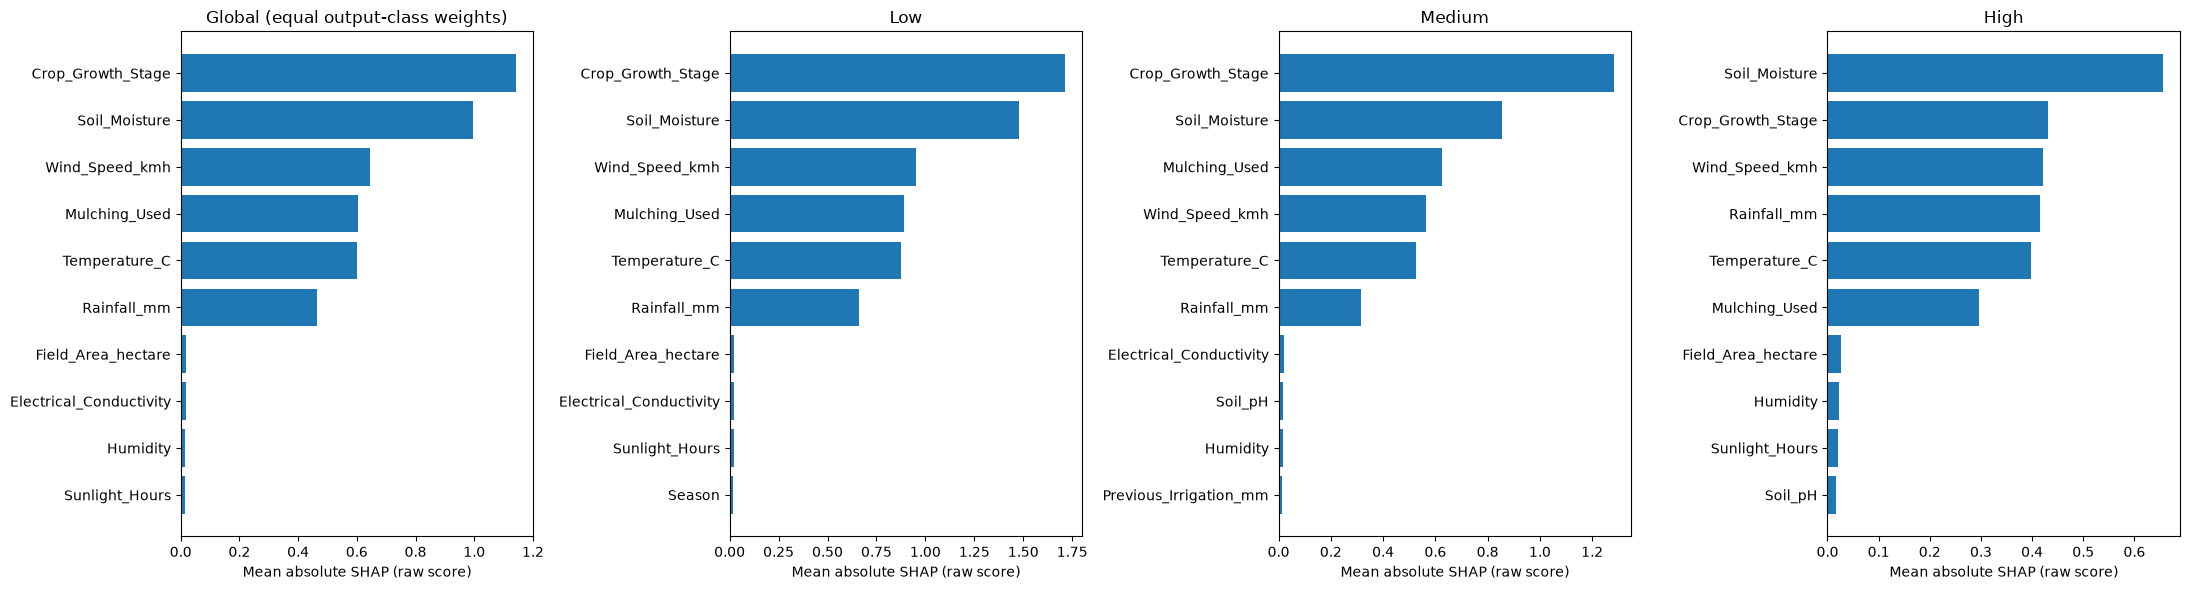

In [17]:
catboost_shap_class_means = np.abs(catboost_shap_values).mean(axis=0)
catboost_shap_importance = pd.DataFrame({
    "Feature": catboost_shap_data.columns,
    "Mean absolute SHAP": catboost_shap_class_means.mean(axis=0),
})
for shap_class_index, shap_class_label in enumerate(catboost_shap_labels):
    catboost_shap_importance[f"Mean absolute SHAP {shap_class_label}"] = (
        catboost_shap_class_means[shap_class_index]
    )
catboost_shap_importance = catboost_shap_importance.sort_values(
    "Mean absolute SHAP", ascending=False
).reset_index(drop=True)
display(catboost_shap_importance.round(4))

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
for ax, shap_column, shap_title in zip(
    axes,
    ["Mean absolute SHAP"] + [f"Mean absolute SHAP {c}" for c in class_labels],
    ["Global (equal output-class weights)"] + class_labels,
):
    shap_top = catboost_shap_importance.nlargest(10, shap_column).sort_values(shap_column)
    ax.barh(shap_top["Feature"], shap_top[shap_column])
    ax.set_title(shap_title)
    ax.set_xlabel("Mean absolute SHAP (raw score)")
fig.tight_layout()
plt.show()

### 6.4. SHAP summary plots for Low, Medium and High

Native SHAP summary dot plots are drawn with Matplotlib, avoiding an additional
dependency. Each dot represents a sampled training observation. The horizontal
axis is signed SHAP for the named output class. Numeric features are colored
by their relative value within each feature (blue: low, red: high); categorical
features are gray because category codes have no meaningful numeric ordering.
Vertical jitter is only for visibility. Categorical effects are also shown by
category below. SHAP is a model attribution, not a causal effect.

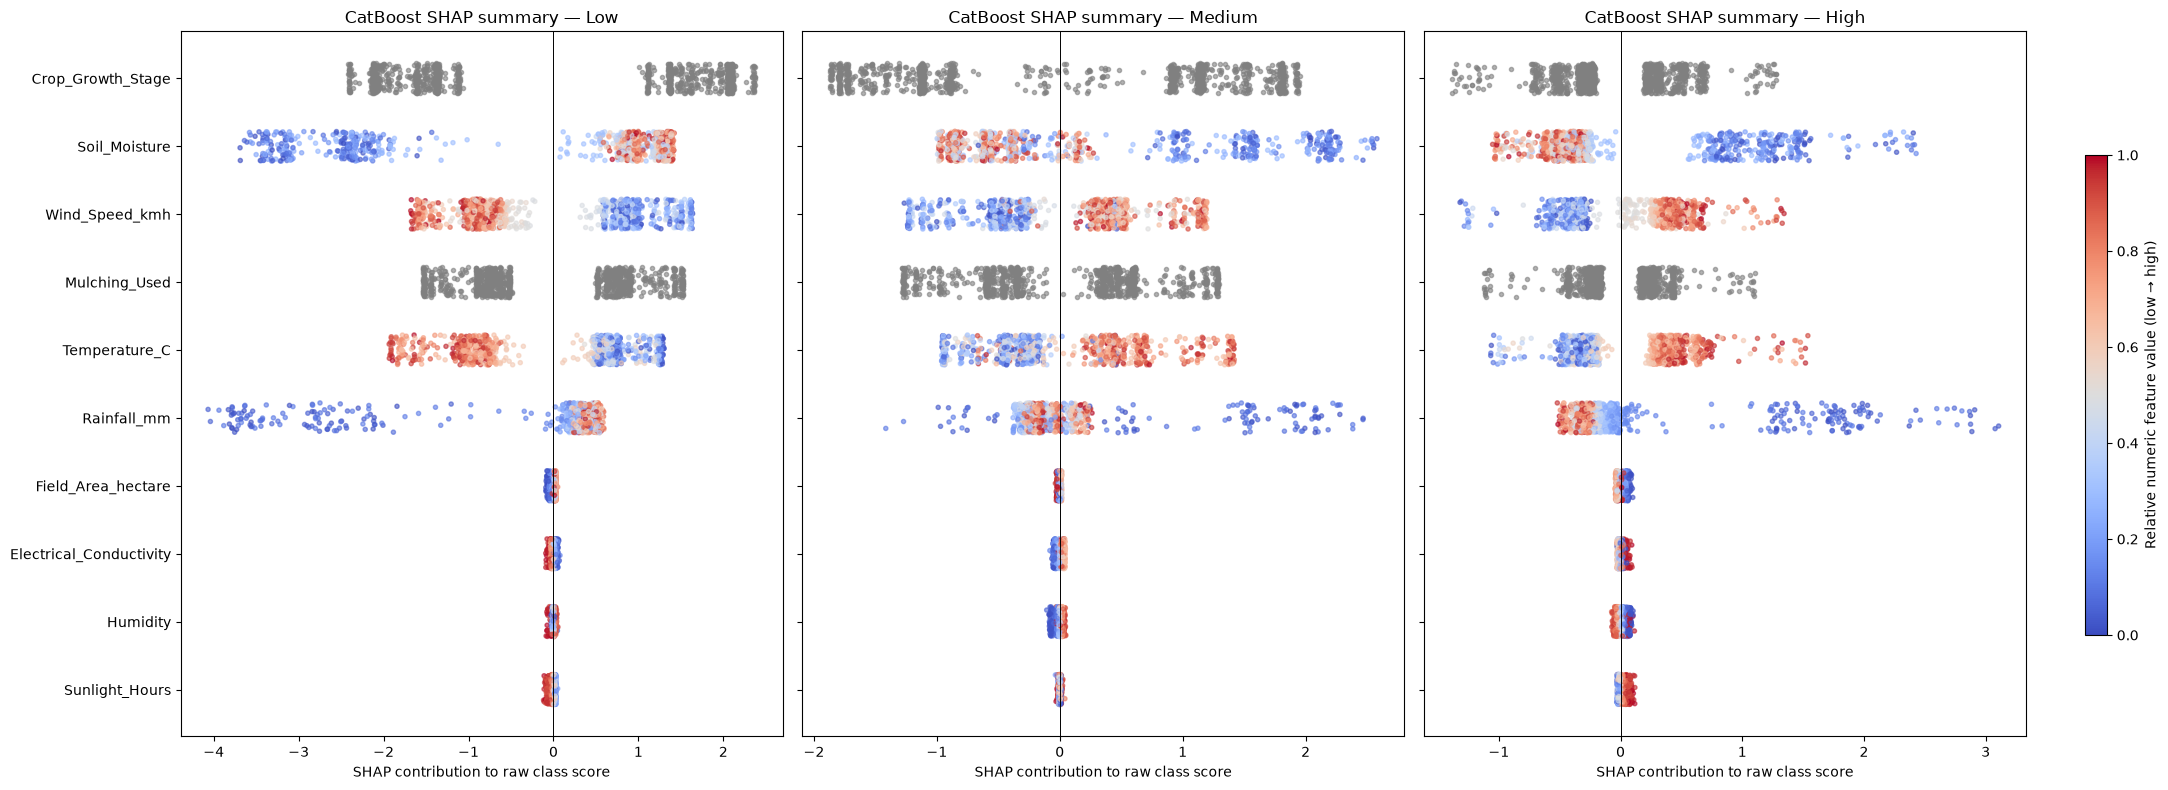

,Feature,Category,Count,Mean SHAP High,Mean SHAP Low,Mean SHAP Medium
0,Crop_Growth_Stage,Flowering,246,0.4189,-1.7494,1.3305
1,Crop_Growth_Stage,Harvest,263,-0.4378,1.7082,-1.2704
2,Crop_Growth_Stage,Sowing,233,-0.4438,1.7005,-1.2567
3,Crop_Growth_Stage,Vegetative,258,0.4267,-1.7024,1.2757
4,Mulching_Used,No,525,0.2922,-0.8869,0.5947
5,Mulching_Used,Yes,475,-0.3002,0.8965,-0.5963


In [18]:
shap_top_features = catboost_shap_importance.head(10)["Feature"].tolist()
shap_plot_rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=True)
for ax, shap_class_label in zip(axes, class_labels):
    shap_class_index = catboost_shap_labels.index(shap_class_label)
    for shap_y, shap_feature in enumerate(reversed(shap_top_features)):
        shap_feature_index = catboost_shap_data.columns.get_loc(shap_feature)
        shap_x = catboost_shap_values[:, shap_class_index, shap_feature_index]
        shap_jitter = shap_y + shap_plot_rng.uniform(-0.22, 0.22, len(shap_x))
        shap_feature_values = catboost_shap_data[shap_feature]
        if pd.api.types.is_numeric_dtype(shap_feature_values):
            shap_range = shap_feature_values.max() - shap_feature_values.min()
            shap_colors = ((shap_feature_values - shap_feature_values.min()) / shap_range
                           if shap_range > 0 else np.full(len(shap_x), 0.5))
            ax.scatter(shap_x, shap_jitter, c=shap_colors, cmap="coolwarm",
                       vmin=0, vmax=1, s=9, alpha=0.6, rasterized=True)
        else:
            ax.scatter(shap_x, shap_jitter, color="gray", s=9, alpha=0.6, rasterized=True)
    ax.axvline(0, color="black", linewidth=0.7)
    ax.set_yticks(range(len(shap_top_features)), list(reversed(shap_top_features)))
    ax.set_title(f"CatBoost SHAP summary — {shap_class_label}")
    ax.set_xlabel("SHAP contribution to raw class score")
fig.tight_layout(rect=[0, 0, 0.93, 1])
shap_color_ax = fig.add_axes([0.95, 0.2, 0.01, 0.6])
fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(0, 1), cmap="coolwarm"),
             cax=shap_color_ax, label="Relative numeric feature value (low → high)")
plt.show()

catboost_shap_categorical_effect_tables = []
for shap_feature in shap_top_features:
    if not pd.api.types.is_numeric_dtype(catboost_shap_data[shap_feature]):
        shap_feature_index = catboost_shap_data.columns.get_loc(shap_feature)
        shap_category_table = pd.DataFrame({
            "Category": catboost_shap_data[shap_feature].to_numpy(),
            **{f"Mean SHAP {label}": catboost_shap_values[:, index, shap_feature_index]
               for index, label in enumerate(catboost_shap_labels)},
        })
        shap_category_group = shap_category_table.groupby("Category", sort=True)
        shap_category_means = shap_category_group.mean()
        shap_category_means.insert(0, "Count", shap_category_group.size())
        shap_category_means = shap_category_means.reset_index()
        shap_category_means.insert(0, "Feature", shap_feature)
        catboost_shap_categorical_effect_tables.append(shap_category_means)
catboost_shap_categorical_effects = pd.concat(
    catboost_shap_categorical_effect_tables, ignore_index=True
) if catboost_shap_categorical_effect_tables else pd.DataFrame()
display(catboost_shap_categorical_effects.round(4))

### 6.5. Conclusions from the executed analysis

The following Markdown is generated from the current CV and SHAP tables.
Drops describe predictive information under fixed model settings, rather than
proof of causal relevance or statistical significance.

In [19]:
from IPython.display import Markdown

extension_conclusion_lines = []
for conclusion_model in ["Decision Tree", "CatBoost"]:
    conclusion_wind = additional_ablation_cv_table.query(
        'Model == @conclusion_model and Variant == "Without Wind_Speed_kmh"'
    ).iloc[0]
    conclusion_six = additional_ablation_cv_table.query(
        'Model == @conclusion_model and Variant == "Without all six selected features"'
    ).iloc[0]
    conclusion_base = additional_baseline.loc[conclusion_model]
    extension_conclusion_lines.append(
        f"- **{conclusion_model}:** removing Wind_Speed_kmh changed Balanced Accuracy "
        f"from {conclusion_base['Balanced Accuracy CV mean']:.4f} to "
        f"{conclusion_wind['Balanced Accuracy CV mean']:.4f} "
        f"(drop {conclusion_wind['Balanced Accuracy drop mean']:.4f}); "
        f"Macro F1 = {conclusion_wind['Macro F1 CV mean']:.4f}, "
        f"Recall High = {conclusion_wind['Recall High CV mean']:.4f}. "
        f"Removing all six yielded Balanced Accuracy "
        f"{conclusion_six['Balanced Accuracy CV mean']:.4f}, "
        f"Macro F1 {conclusion_six['Macro F1 CV mean']:.4f} and "
        f"Recall High {conclusion_six['Recall High CV mean']:.4f}."
    )
wind_mean_drops = additional_ablation_cv_table.query(
    'Variant == "Without Wind_Speed_kmh"'
)["Balanced Accuracy drop mean"]
if (wind_mean_drops > 0).all():
    extension_conclusion_lines.append(
        "- Lower mean Balanced Accuracy after removing wind in both models supports "
        "additional predictive information that the remaining features do not fully "
        "replace under this protocol. This is not proof of causality or statistical significance."
    )
else:
    extension_conclusion_lines.append(
        "- The mean Balanced Accuracy drops do not consistently support additional "
        "predictive value of wind in both models under this protocol."
    )
extension_conclusion_lines.append(
    "- **Global SHAP ranking:** " + ", ".join(catboost_shap_importance.head(6)["Feature"]) + "."
)
for conclusion_class in class_labels:
    conclusion_top = catboost_shap_importance.nlargest(
        3, f"Mean absolute SHAP {conclusion_class}"
    )["Feature"].tolist()
    extension_conclusion_lines.append(
        f"- **SHAP for {conclusion_class}:** " + ", ".join(conclusion_top) + "."
    )
extension_conclusion_lines.append(
    "- SHAP explains raw class scores of the fitted model on sampled training data; "
    "it does not identify causal effects. Near-perfect scores establish neither absence "
    "of leakage nor rule-based target generation. Both require separate provenance checks."
)
extension_conclusions = "\n".join(extension_conclusion_lines)
display(Markdown(extension_conclusions))

- **Decision Tree:** removing Wind_Speed_kmh changed Balanced Accuracy from 0.9780 to 0.7942 (drop 0.1838); Macro F1 = 0.7911, Recall High = 0.6688. Removing all six yielded Balanced Accuracy 0.3321, Macro F1 0.3318 and Recall High 0.0410.
- **CatBoost:** removing Wind_Speed_kmh changed Balanced Accuracy from 0.9941 to 0.7752 (drop 0.2189); Macro F1 = 0.7825, Recall High = 0.6170. Removing all six yielded Balanced Accuracy 0.3368, Macro F1 0.2747 and Recall High 0.0000.
- Lower mean Balanced Accuracy after removing wind in both models supports additional predictive information that the remaining features do not fully replace under this protocol. This is not proof of causality or statistical significance.
- **Global SHAP ranking:** Crop_Growth_Stage, Soil_Moisture, Wind_Speed_kmh, Mulching_Used, Temperature_C, Rainfall_mm.
- **SHAP for Low:** Crop_Growth_Stage, Soil_Moisture, Wind_Speed_kmh.
- **SHAP for Medium:** Crop_Growth_Stage, Soil_Moisture, Mulching_Used.
- **SHAP for High:** Soil_Moisture, Crop_Growth_Stage, Wind_Speed_kmh.
- SHAP explains raw class scores of the fitted model on sampled training data; it does not identify causal effects. Near-perfect scores establish neither absence of leakage nor rule-based target generation. Both require separate provenance checks.